In [7]:
from pathlib import Path
from return_after_jump.utils import (
    get_db_connection,
    analyse_group, conduct_hypothesis_test
)

## Parameters
1. Database path
2. Direction of the jump in price
3. The parameter of interest (e.g. percentage of positive return, mean return, volume etc.)
4. Time horizon after the shock

These parameters can be adjusted to suit different analysis

In [8]:
db_path = Path('data\\data.db')
jump_dir = 'positive'
param_of_interest = 'perc_positive'
t = 1

In [9]:
con = get_db_connection(db_path)

## Analyse each stock group

The S&P500 sample and the micro-cap sample are analysed separately
The stock level outputs will later be compared across the two groups

In [10]:
sp_dict = analyse_group(con, 'sp500', 'sp_prices_daily', jump_dir, param_of_interest, t)
micro_dict = analyse_group(con, 'micro', 'micro_prices_daily', jump_dir, param_of_interest, t)

## Hypothesis Test
Test whether the parameter of interest differs significantly across the two stock groups

In [11]:
conduct_hypothesis_test(sp_dict, micro_dict)

Mean of list1: 47.44749558804957
Mean of list2: 44.922795752288216
t-statistic: 4.676609586663327
p-value: 3.4584441528220085e-06


## Interpretation
1. Percentage of positive returns after positive jump in price
- The percentage for micro cap stocks is statistically significant lower than that of the S&P500 stocks
- Potenial Reason 1: Research by Frank, Sanati (2018) has shown that price jumps can be either due to fundamental or non-fundamental reasons. For non-fundamental reasons, price reversal is more likely to happen. Compared to large stocks, micro-cap stocks tend to be less liquid, receive lower institutional coverage and are more prone to non-fundamental shocks (such as liquidity reasons). As such, price reversals are more likely to occur for micro-cap stocks due to the lack of rationality involved.
- Potential Reason 2: Order book is thin for micro-cap shocks, creating wider bid-ask spreads, hence jumps may be entirely arbitrary
- Potential Reason 3: Micro-cap stocks are harder to arbitrage, causing potentially larger mispricing and thus corrections

To confirm the second and third reasons, frequency of the micro-cap stock shocks can be analysed and compared against large cap

## Limitation
When conducting hypothesis testing, it is assumed that the two samples are independently drawn. But this is clearly not the case since both micro-cap and large-cap companies are exposed to the same set of systematic market risks, severely undermining the validity of the results

## Possible Next Steps
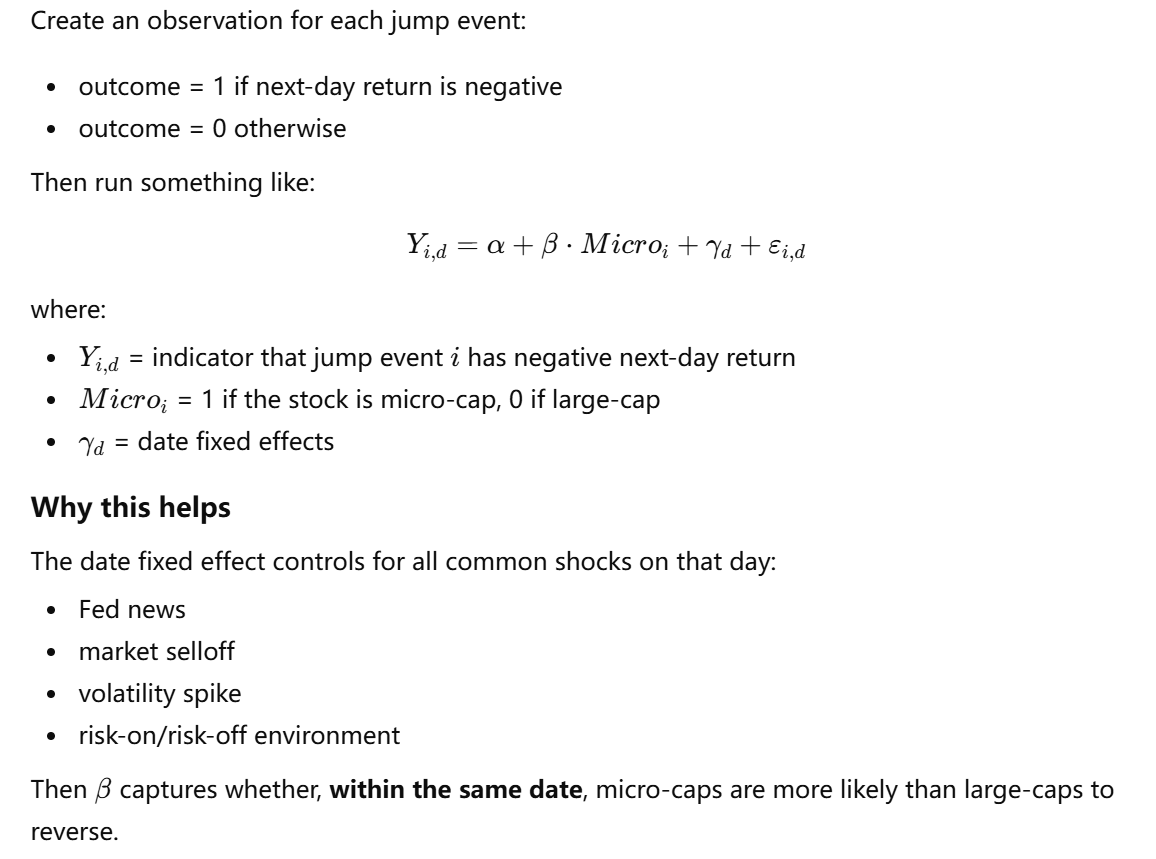
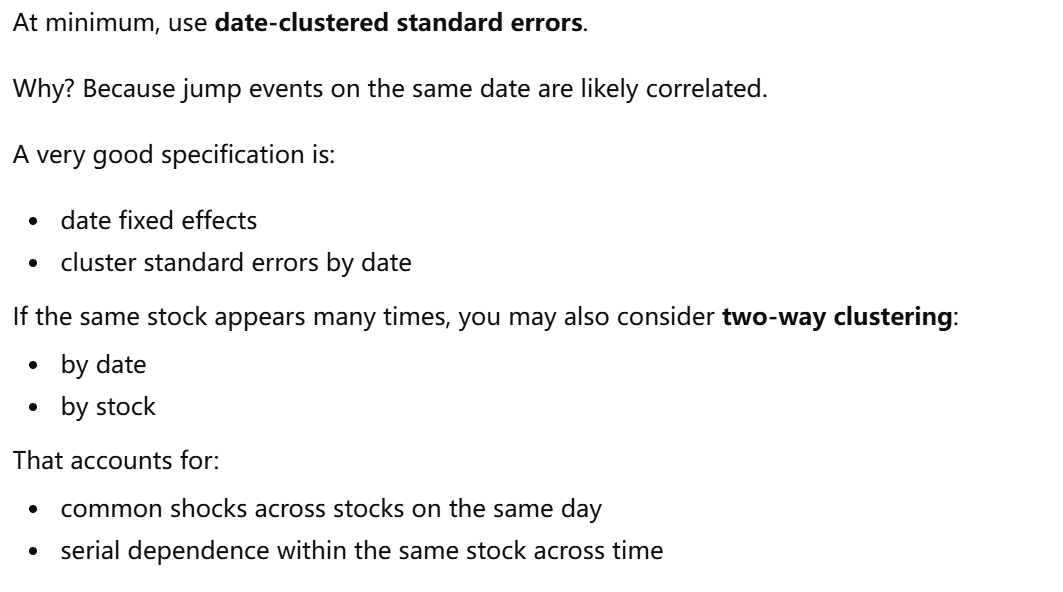